# **Proyecto: Clasificación de imágenes aplicando filtros**

###  **Elizabeth Martínez Valeria**

Se utilizó la base de datos CIFAR-10, la cual contiene 60,000 imágenes distribuidas en 10 categorías diferentes (por ejemplo: avión, automóvil, pájaro, gato, etc.). Para este proyecto, se tomaron las primeras 5 imágenes.
Y se aplicó el filtro Sobel para detectar bordes en las imágenes.

#### **Justificación del Filtro Elegido**

El filtro de Sobel permite resaltar los contornos y estructuras dentro de una imagen. Es útil para la detección de formas y límites, lo que facilita la posterior clasificación de las imágenes por sus características visuales principales. A diferencia de filtros como el de desenfoque o mediana, el Sobel conserva y destaca los elementos estructurales esenciales de una imagen. Es computacionalmente ligero, lo que permite procesar grandes volúmenes de imágenes de forma eficiente.




In [1]:
# Subir el archivo
from google.colab import files
uploaded = files.upload()  # Aquí subes el .tar.gz

# Descomprimir
import tarfile

with tarfile.open("cifar-10-python.tar.gz", "r:gz") as tar:
    tar.extractall()
archivo = "cifar-10-batches-py/data_batch_1"


Saving cifar-10-python.tar.gz to cifar-10-python.tar (1).gz


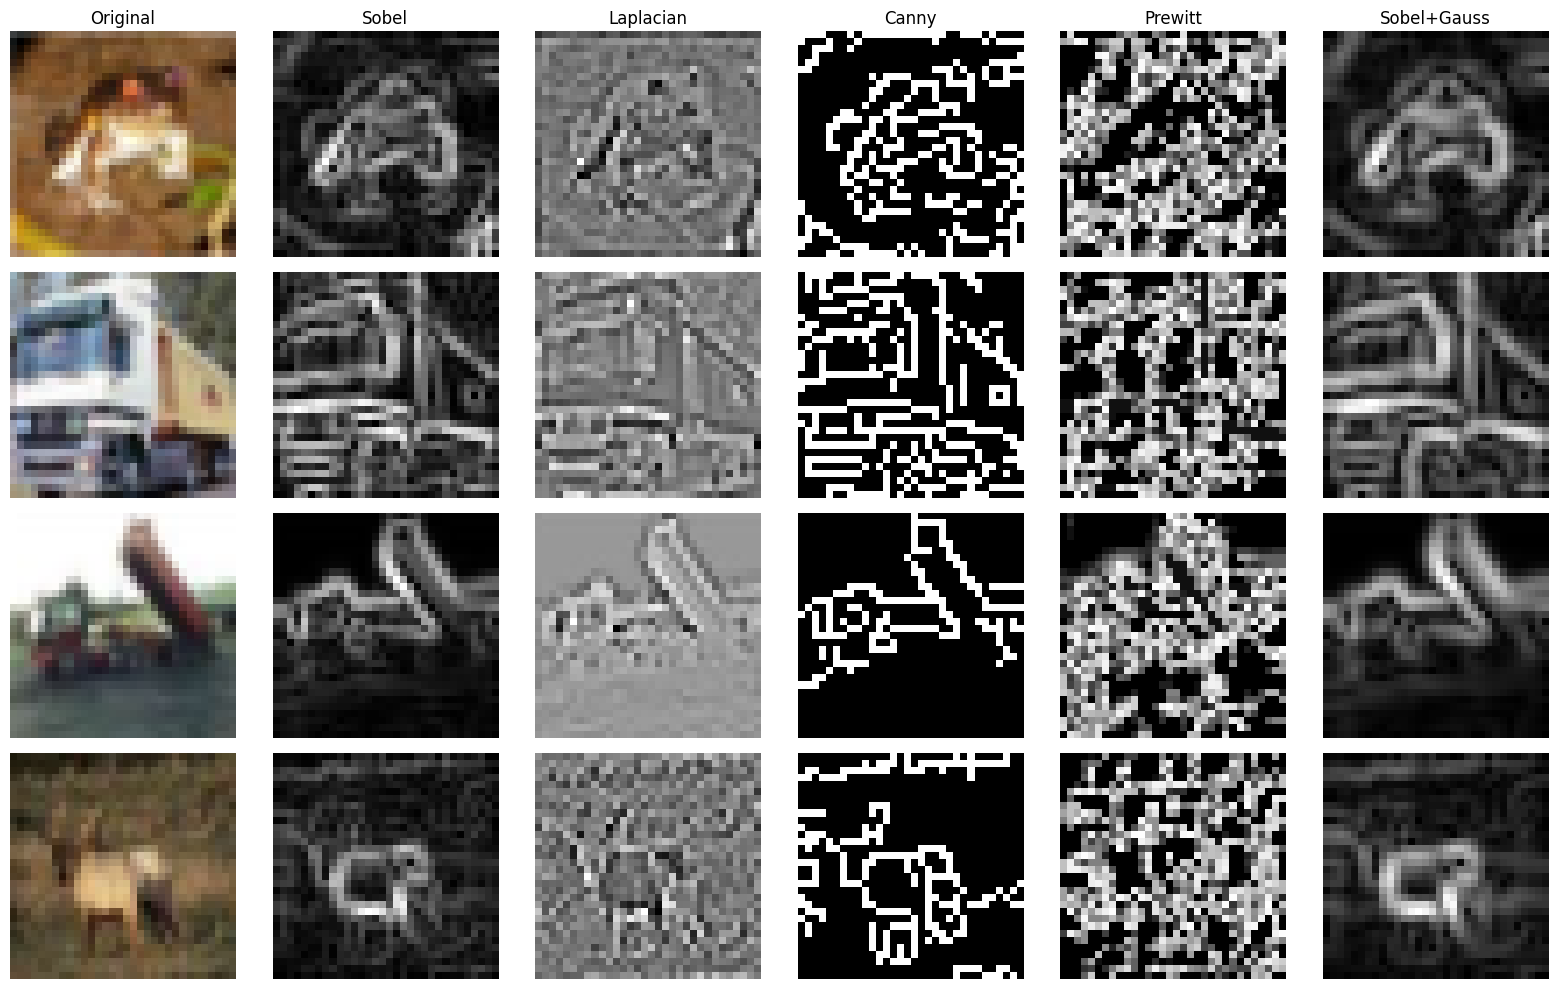

In [7]:
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# Función para cargar un batch
def cargar_batch(archivo):
    with open(archivo, 'rb') as f:
        dict = pickle.load(f, encoding='bytes')
    data = dict[b'data']
    labels = dict[b'labels']
    data = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # Convertir a (N, 32, 32, 3)
    return data, labels

# Cargar imágenes del batch
imagenes, etiquetas = cargar_batch(archivo)

# Seleccionar primeras 4 imágenes para mejor visualización
imagenes = imagenes[:4]

# Procesar y aplicar múltiples filtros
imagenes_filtradas = {'Original': imagenes.copy()}

for img in imagenes:
    gris = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Filtro Sobel
    sobelx = cv2.Sobel(gris, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gris, cv2.CV_64F, 0, 1, ksize=3)
    magnitud = np.sqrt(sobelx**2 + sobely**2)
    sobel_img = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Filtro Laplaciano
    laplacian = cv2.Laplacian(gris, cv2.CV_64F)
    laplacian_img = cv2.normalize(laplacian, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Filtro Canny
    canny_img = cv2.Canny(gris, 100, 200)

    # Filtro Prewitt - Versión más robusta
    kernelx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
    kernely = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    prewittx = cv2.filter2D(gris, -1, kernelx)
    prewitty = cv2.filter2D(gris, -1, kernely)
    prewitt_mag = np.sqrt(prewittx**2 + prewitty**2)

    # Normalización manual para Prewitt (evitamos cv2.normalize)
    min_val = prewitt_mag.min()
    max_val = prewitt_mag.max()
    if max_val > min_val:
        prewitt_img = ((prewitt_mag - min_val) * (255.0 / (max_val - min_val))).astype(np.uint8)
    else:
        prewitt_img = np.zeros_like(gris, dtype=np.uint8)

    # Filtro Gaussiano + Sobel
    blurred = cv2.GaussianBlur(gris, (3, 3), 0)
    sobelx_blur = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobely_blur = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    sobel_blur_mag = np.sqrt(sobelx_blur**2 + sobely_blur**2)
    sobel_blur_img = cv2.normalize(sobel_blur_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Guardar todas las versiones
    if 'Sobel' not in imagenes_filtradas:
        imagenes_filtradas['Sobel'] = []
        imagenes_filtradas['Laplacian'] = []
        imagenes_filtradas['Canny'] = []
        imagenes_filtradas['Prewitt'] = []
        imagenes_filtradas['Sobel+Gauss'] = []

    imagenes_filtradas['Sobel'].append(sobel_img)
    imagenes_filtradas['Laplacian'].append(laplacian_img)
    imagenes_filtradas['Canny'].append(canny_img)
    imagenes_filtradas['Prewitt'].append(prewitt_img)
    imagenes_filtradas['Sobel+Gauss'].append(sobel_blur_img)

plt.figure(figsize=(16, 10))
filtros = list(imagenes_filtradas.keys())

for i in range(4):
    for j, filtro in enumerate(filtros):
        plt.subplot(4, len(filtros), i*len(filtros) + j + 1)
        if filtro == 'Original':
            plt.imshow(imagenes_filtradas[filtro][i])
        else:
            plt.imshow(imagenes_filtradas[filtro][i], cmap='gray')
        plt.title(f"{filtro}" if i == 0 else "")
        plt.axis('off')

plt.tight_layout()
plt.show()

# **Conclusiones**

1. Filtro Sobel

Ventajas: Detecta bien los bordes horizontales y verticales.
Resultados suaves y continuos.

Limitaciones: Menos efectivo en bordes diagonales (comparado con Scharr). Puede perder detalles finos.

2. Filtro Laplaciano

Ventajas: Destaca bordes en todas las direcciones (no solo ejes principales). Resalta cambios bruscos de intensidad.

Limitaciones: Más sensible al ruido (se observan pequeños artefactos). Bordes menos definidos que Canny.

3. Filtro Canny

Ventajas: El más preciso para detección de bordes finos.Bordes delgados y bien definidos (gracias a la histéresis de umbrales).

Limitaciones: Requiere ajuste manual de umbrales (50/150 en este caso).
Puede perder bordes débiles si los umbrales son altos.

4. Filtro Prewitt

Ventajas: Similar a Sobel, pero con kernels más simples.

Buen equilibrio entre rendimiento y velocidad.

Limitaciones:
Menor sensibilidad que Sobel/Scharr.
Bordes más gruesos y menos precisos.

5. Sobel + Gaussiano

Ventajas:
Reduce el ruido antes de detectar bordes (gracias al suavizado gaussiano).

Bordes más limpios que Sobel estándar.

Limitaciones: Puede suavizar demasiado, perdiendo detalles finos.